# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

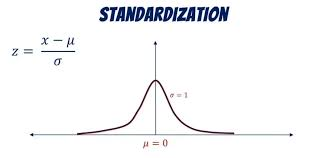


In [37]:
import numpy as np

dataset_url = 'https://data.iita.org/dataset/20fb4060-ad36-4693-ab56-26edc1392867/resource/a78fcdc5-57a5-4666-9886-25b75dc5c46c/download/fruits.csv'

converters = {
    1: lambda s: float(s) if s.strip() else np.nan,
    2: lambda s: float(s) if s.strip() else np.nan,
    3: lambda s: float(s) if s.strip() else np.nan
}

data = np.genfromtxt(dataset_url, delimiter=',', dtype=None, encoding='utf-8', names=True, converters=converters, missing_values='NA')

print("Loaded data (first 5 rows):")
for i in range(min(5, len(data))):
    print(data[i])

print(f"\nShape of the loaded data: {data.shape}")
print(f"Data type of the loaded data: {data.dtype}")
print(f"Column names: {data.dtype.names}")

Loaded data (first 5 rows):
(1, 9.4, 8.1, 301.0, 8, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(2, 7.6, 6.5, 181.0, 3, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(3, 8.54, 8.1, 371.0, 9, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(4, 9.3, 8.54, 455.0, 10, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(5, 9.53, 7.5, 373.0, 7, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')

Shape of the loaded data: (47,)
Data type of the loaded data: [('No_of_fruit', '<i8'), ('Length_fruit_cm', '<f8'), ('Diameter_cm', '<f8'), ('weigth_g', '<f8'), ('Num_of_seed_fruit', '<i8'), ('state_of_the_fruit', '<U8'), ('Harvest_Date', '<U9'), ('Date_collected_data', '<U9'), ('Origin', '<U8'), ('f0', '?'), ('f1', '?'), ('f2', '?'), ('f3', '?'), ('f4', '<U1')]
Column names: ('No_of_fruit', 'Length_fruit_cm', 'Diameter_cm', 'weigth_g', 'N

In [38]:

numerical_cols = []
for name in data.dtype.names:
    if data[name].dtype.kind in ('i', 'f'):
        numerical_cols.append(name)

if 'fruit_id' in numerical_cols:
    numerical_cols.remove('fruit_id')

if len(numerical_cols) == 0:
    print("No numerical columns found for standardization.")
else:
    data_standardized = data.copy()

    for col in numerical_cols:
        col_data = data_standardized[col]

        mean = np.nanmean(col_data)
        std_dev = np.nanstd(col_data)

        if std_dev == 0 or np.isnan(std_dev):
            data_standardized[col] = np.zeros_like(col_data, dtype=float)
        else:
            data_standardized[col] = (col_data - mean) / std_dev

    print("Standardized data (first 5 rows for numerical columns):")
    for i in range(min(5, len(data_standardized))):
        row_output = []
        for col in numerical_cols:
            row_output.append(f"{col}: {data_standardized[col][i]:.4f}")
        print(", ".join(row_output))

    print("\nDescriptive statistics of standardized numerical columns:")
    for col in numerical_cols:
        print(f"Column '{col}': Mean={np.nanmean(data_standardized[col]):.2f}, Std Dev={np.nanstd(data_standardized[col]):.2f}")

Standardized data (first 5 rows for numerical columns):
No_of_fruit: -1.0000, Length_fruit_cm: 0.9510, Diameter_cm: 0.9871, weigth_g: 0.7486, Num_of_seed_fruit: 0.0000
No_of_fruit: -1.0000, Length_fruit_cm: 0.5377, Diameter_cm: 0.5556, weigth_g: -0.0059, Num_of_seed_fruit: -1.0000
No_of_fruit: -1.0000, Length_fruit_cm: 0.7536, Diameter_cm: 0.9871, weigth_g: 1.1888, Num_of_seed_fruit: 0.0000
No_of_fruit: -1.0000, Length_fruit_cm: 0.9281, Diameter_cm: 1.1057, weigth_g: 1.7170, Num_of_seed_fruit: 1.0000
No_of_fruit: -1.0000, Length_fruit_cm: 0.9809, Diameter_cm: 0.8253, weigth_g: 1.2014, Num_of_seed_fruit: 0.0000

Descriptive statistics of standardized numerical columns:
Column 'No_of_fruit': Mean=0.00, Std Dev=0.65
Column 'Length_fruit_cm': Mean=0.00, Std Dev=1.00
Column 'Diameter_cm': Mean=0.00, Std Dev=1.00
Column 'weigth_g': Mean=0.00, Std Dev=1.00
Column 'Num_of_seed_fruit': Mean=-0.06, Std Dev=0.63


In [39]:
print("First 5 rows of standardized data (all columns):")
for i in range(min(5, len(data_standardized))):
    print(data_standardized[i])

First 5 rows of standardized data (all columns):
(-1, 0.9510499953273001, 0.9870828228670266, 0.7486496309983436, 0, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(-1, 0.5377199346846945, 0.5555712063131354, -0.005886451709064805, -1, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(-1, 0.7535700774647216, 0.9870828228670266, 1.188795679244332, 0, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(-1, 0.9280872141804887, 1.1057485174193467, 1.7169709371395179, 1, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')
(-1, 0.9809016108181546, 0.8252659666593175, 1.2013712806227888, 0, 'Healthy', '9/28/2017', '9/29/2017', 'Mbalmayo', False, False, False, False, '')


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [40]:
 import numpy as np

if 'data_standardized' not in globals() or 'numerical_cols' not in globals():
    print("Please run previous cells to define 'data_standardized' and 'numerical_cols'.")
else:
    numerical_data_for_cov = np.stack([data_standardized[col].astype(float) for col in numerical_cols], axis=-1)

    nan_mask = np.any(np.isnan(numerical_data_for_cov), axis=1)
    numerical_data_for_cov_cleaned = numerical_data_for_cov[~nan_mask]

    if numerical_data_for_cov_cleaned.shape[0] < 2:
        print("Not enough data points to calculate covariance matrix after removing NaNs (need at least 2 rows).")
    else:
        covariance_matrix = np.cov(numerical_data_for_cov_cleaned, rowvar=False)

        print("Covariance Matrix of the numerical data (cleaned from NaNs):")
        print(" " * 10 + " ".join([f'{col:>10}' for col in numerical_cols]))
        for i, row in enumerate(covariance_matrix):
            print(f'{numerical_cols[i]:<10}' + " ".join([f'{val:10.6f}' for val in row]))

Covariance Matrix of the numerical data (cleaned from NaNs):
          No_of_fruit Length_fruit_cm Diameter_cm   weigth_g Num_of_seed_fruit
No_of_fruit  0.434783  -0.449971  -0.447224  -0.447664   0.086957
Length_fruit_cm -0.449971   1.021739   1.012540   0.982129  -0.028579
Diameter_cm -0.447224   1.012540   1.021739   0.999228   0.006508
weigth_g   -0.447664   0.982129   0.999228   1.021739   0.068866
Num_of_seed_fruit  0.086957  -0.028579   0.006508   0.068866   0.408881


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [41]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors =  np.linalg.eigh(covariance_matrix)
eigenvalues, eigenvectors

(array([0.00603133, 0.02688817, 0.18717597, 0.45562443, 3.23316077]),
 array([[ 0.0130376 , -0.09552488,  0.89567657,  0.34205281, -0.26733568],
        [ 0.5733889 ,  0.55242636,  0.23370987, -0.04480634,  0.55625747],
        [-0.78751498,  0.17981931,  0.18359952,  0.03634876,  0.55897688],
        [ 0.22523176, -0.7828814 ,  0.01286345,  0.17189722,  0.55376281],
        [ 0.01208258,  0.2011513 , -0.3305585 ,  0.92202081,  0.00093097]]))

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [42]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-0.26733568,  0.34205281,  0.89567657, -0.09552488,  0.0130376 ],
       [ 0.55625747, -0.04480634,  0.23370987,  0.55242636,  0.5733889 ],
       [ 0.55897688,  0.03634876,  0.18359952,  0.17981931, -0.78751498],
       [ 0.55376281,  0.17189722,  0.01286345, -0.7828814 ,  0.22523176],
       [ 0.00093097,  0.92202081, -0.3305585 ,  0.2011513 ,  0.01208258]])

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [43]:
#step 6: Project Data onto Principal Components
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

threshold = 0.90  # retain at least 90% of total variance
num_components = np.argmax(cumulative_variance >= threshold) + 1

print("Explained variance ratio per component:", np.round(explained_variance_ratio, 4))
print("Cumulative variance:", np.round(cumulative_variance, 4))
print(f"Components selected to retain {threshold:.0%} of variance: {num_components}")

Explained variance ratio per component: [0.8271 0.1166 0.0479 0.0069 0.0015]
Cumulative variance: [0.8271 0.9437 0.9916 0.9985 1.    ]
Components selected to retain 90% of variance: 2


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [44]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')

explained_variance = sorted_eigenvalues[:num_components] / np.sum(sorted_eigenvalues)
print(f'Variance explained by PC1: {explained_variance[0]:.2%}')
print(f'Variance explained by PC2: {explained_variance[1]:.2%}')
print(f'Total variance retained: {np.sum(explained_variance):.2%}')

print("\nFirst 5 rows of reduced data:")
print(reduced_data[:5])

Reduced Data Shape: (47, 2)
Variance explained by PC1: 82.71%
Variance explained by PC2: 11.66%
Total variance retained: 94.37%

First 5 rows of reduced data:
[[ 1.76269514 -0.22009585]
 [ 0.8728072  -1.26898443]
 [ 1.89658197 -0.13558761]
 [ 2.3534046   0.87371893]
 [ 1.93954885 -0.14949364]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

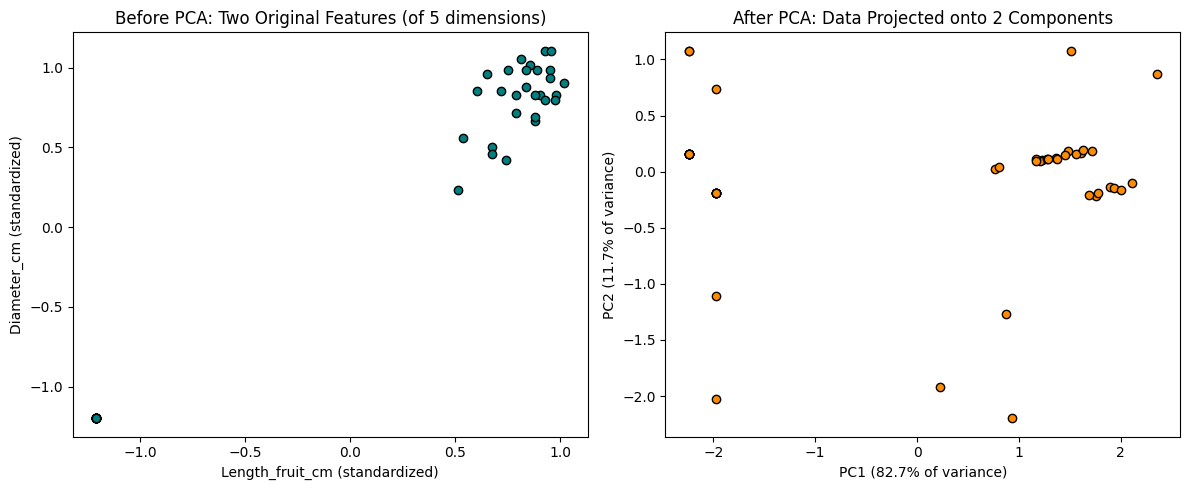

In [45]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

var_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before PCA: two of the original standardized features
axes[0].scatter(numerical_data_for_cov_cleaned[:, 1],   # Length_fruit_cm
                numerical_data_for_cov_cleaned[:, 2],   # Diameter_cm
                c='teal', edgecolor='k')
axes[0].set_xlabel('Length_fruit_cm (standardized)')
axes[0].set_ylabel('Diameter_cm (standardized)')
axes[0].set_title('Before PCA: Two Original Features (of 5 dimensions)')

# After PCA: the two selected principal components
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1],
                c='darkorange', edgecolor='k')
axes[1].set_xlabel(f'PC1 ({var_ratio[0]:.1%} of variance)')
axes[1].set_ylabel(f'PC2 ({var_ratio[1]:.1%} of variance)')
axes[1].set_title('After PCA: Data Projected onto 2 Components')

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


### Answers ###

1. The first graph shows the original data showing x = Length_fruit_cm and y= Diameter_cm
The first graph shows a high correlation between the two components (Length_fruit_cm and Diameter_cm).
The second graph (after PCA) shows the dataset using only 2 components to represent the whole dataset. It shows hidden patterns (trends) that we couldn't see in the first graph because we have compressed the data into two dimensions. The outliers in the first graph (before PCA) are more extreme compared to the second graph (after PCA)

2. We chose two principal components to visualize the dataset easily, and the reason why we chose "Length_fruit_cm" and "Diameter_cm" is because they have a higher impact on the dataset, which means a higher variance compared to the other components. Length_fruit_cm has a variance of 82.7% and Diameter_cm has a variance 11.6%; so combined together they form a total variance of 94.4% which is a very high variance and shows the overall trends of the dataset. However, there's a 6% of information that is lost which are minor details but we remain with the most important information.

3. When reducing dimensions we lose information like the weight of the fruit (weight_g) and the number of seeds they have (number_seed_fruit) even though they don't contribute to the overall trend of the dataset.